In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from ant.market import Market, BaseAgent
from ant.decentralised.direct import ProportionalAgent, GreedyAgent, EqualDivisionAgent, OptimalAgent
from ant.decentralised.special_strategies import EgalitarianAgent, PettyAgent, ImitationAgent, SatisficingAgent, MixedAgent
from ant.centralised import P4

In [2]:
market_size = 20
simulation_length = 400
num_repeats = 30

graph_types = ["complete", "random", "grid", "scale-free", "small-world"]

weight_distributions = [
    [1.0, 0.0],
    [0.8, 0.2],
    [0.5, 0.5],
    [0.2, 0.8],
    [0.0, 1.0]
]

# We will test mixing Greedy and Egalitarian as an example pair (from user's previous 15+15 prompt examples)
mixed_strategies_to_test = [GreedyAgent, EgalitarianAgent]

# Dictionary to store all simulation results across the repeats
all_results = {f"{w[0]}_G_vs_{w[1]}_E": {gtype: [] for gtype in graph_types} for w in weight_distributions}

In [3]:
for repeat in range(num_repeats):
    print(f"Running repeat {repeat + 1}/{num_repeats}...")
    current_seed = 657849724 + repeat
    
    # Generate the Networks ensuring connectivity where required
    rnd_seed = current_seed
    random_graph = nx.gnp_random_graph(market_size, 0.2, seed=rnd_seed)
    while not nx.is_connected(random_graph):
        rnd_seed += 1000  
        random_graph = nx.gnp_random_graph(market_size, 0.2, seed=rnd_seed)
    
    graphs = {
        "complete": nx.complete_graph(market_size),
        "random": random_graph,
        "grid" : nx.convert_node_labels_to_integers(nx.grid_2d_graph(int(market_size / 4), 4)),
        "scale-free" : nx.barabasi_albert_graph(market_size, 1, seed=current_seed),
        "small-world": nx.connected_watts_strogatz_graph(market_size, int(market_size / 2), 0.05, seed=current_seed),
    }

    for graph_type, graph in graphs.items():
        for weights in weight_distributions:
            # Build agents holding the homogeneous weights
            mixed_agents = []
            for i in range(market_size):
                mixed_agents.append(MixedAgent(
                    id=i, 
                    seed=current_seed + i,
                    strategies=mixed_strategies_to_test,
                    weights=weights
                ))
                
            _market = Market(
                market_size, graph=graph, agents=mixed_agents, seed=current_seed, agent_type=MixedAgent
            )
            
            # Reattach market and initialize properties properly
            for agent in _market.agents:
                agent.market = _market
                agent.received = np.zeros(market_size, dtype=float)
                agent.received_history = np.zeros((10000, market_size), dtype=float)

            optimal_aloc, utility_vec = P4(_market)
            _market.set_market_equilibrium(optimal_aloc, utility_vec)
            
            simulated_state = _market.simulate(simulation_length)
            
            # Record result
            dict_key = f"{weights[0]}_G_vs_{weights[1]}_E"
            all_results[dict_key][graph_type].append(simulated_state)

Running repeat 1/30...
Running repeat 2/30...
Running repeat 3/30...
Running repeat 4/30...
Running repeat 5/30...
Running repeat 6/30...
Running repeat 7/30...
Running repeat 8/30...
Running repeat 9/30...
Running repeat 10/30...
Running repeat 11/30...
Running repeat 12/30...
Running repeat 13/30...
Running repeat 14/30...
Running repeat 15/30...
Running repeat 16/30...
Running repeat 17/30...
Running repeat 18/30...
Running repeat 19/30...
Running repeat 20/30...
Running repeat 21/30...
Running repeat 22/30...
Running repeat 23/30...
Running repeat 24/30...
Running repeat 25/30...
Running repeat 26/30...
Running repeat 27/30...
Running repeat 28/30...
Running repeat 29/30...
Running repeat 30/30...


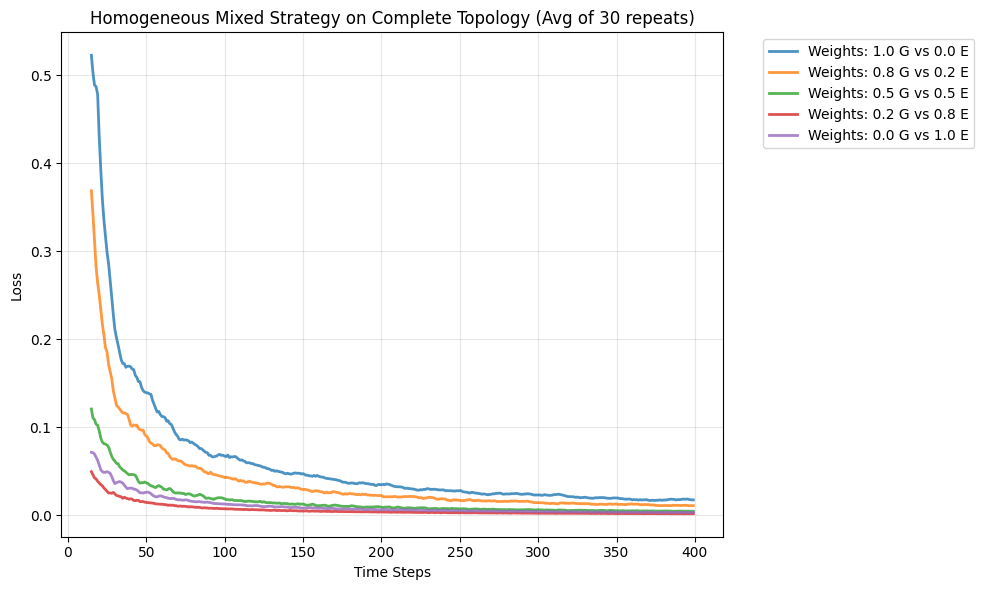

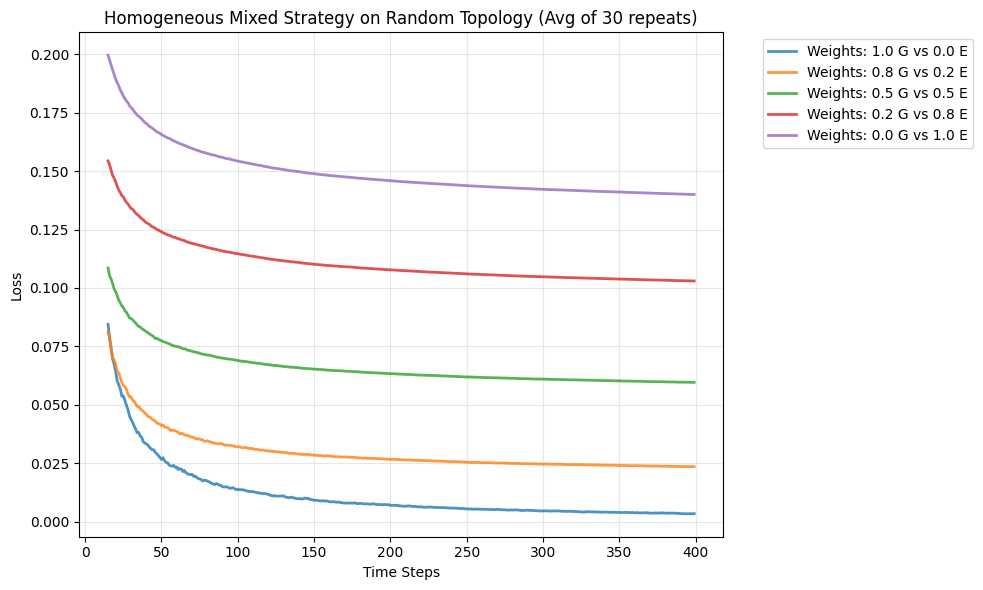

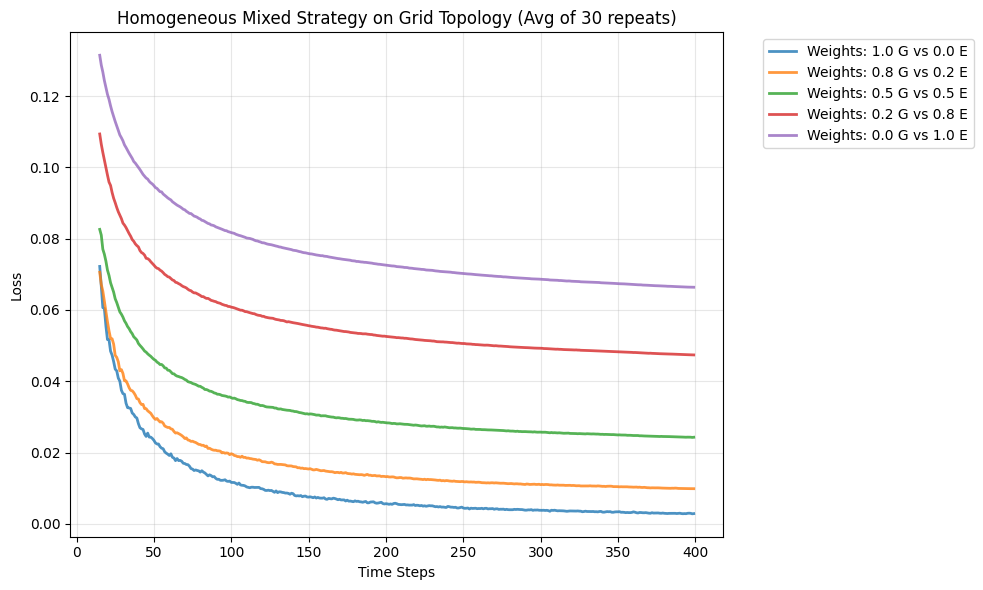

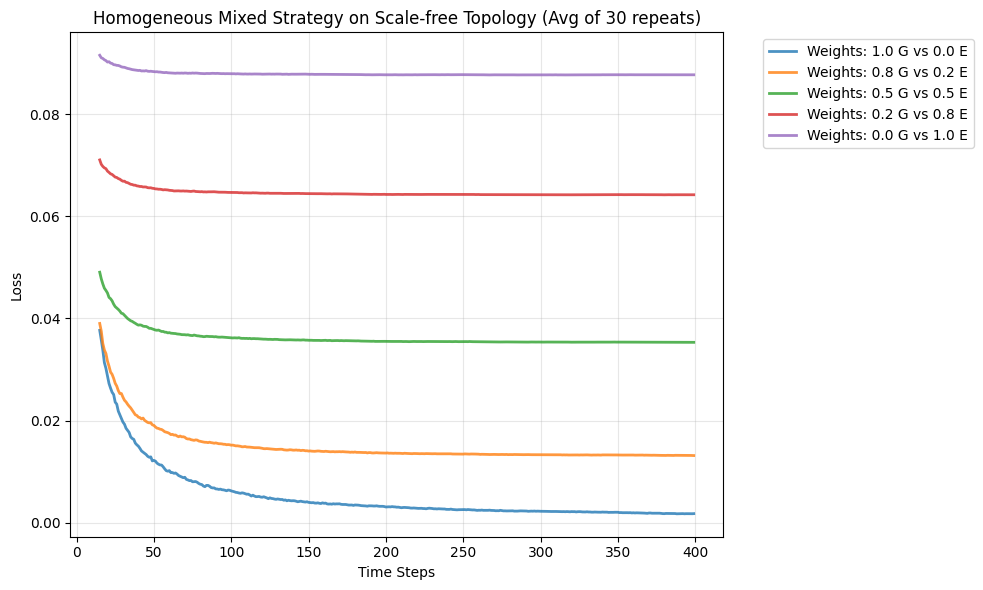

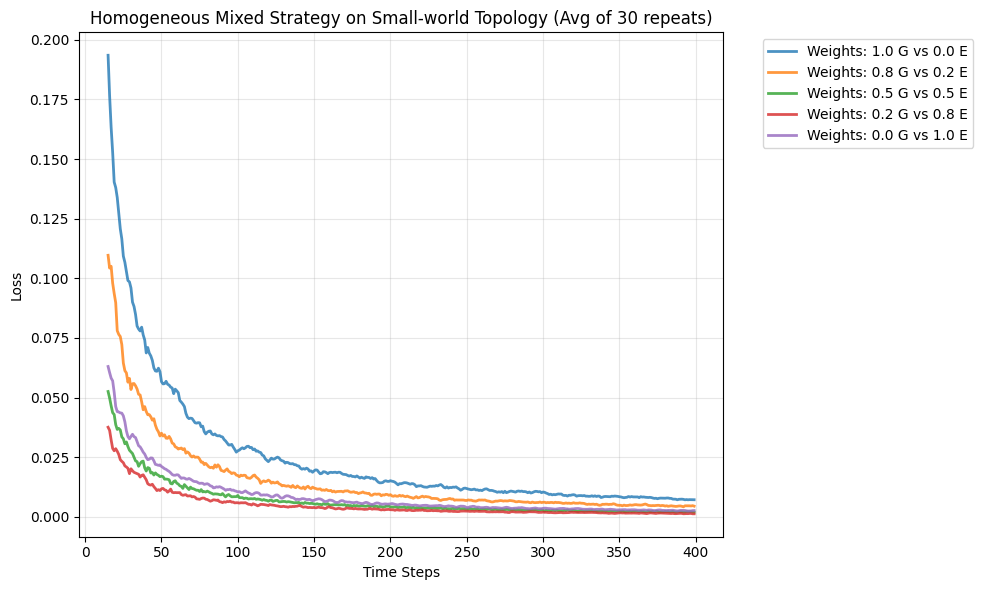

In [4]:
training_period = 15
time_steps = np.arange(training_period, simulation_length)

# Generate a list of distinct colors
colors = plt.cm.tab10.colors

for graph_type in graph_types:
    plt.figure(figsize=(10, 6))
    
    for idx, weight_key in enumerate(all_results.keys()):
        states_array = np.array(all_results[weight_key][graph_type])
        
        # Calculate the average loss per timestep across the repeats
        avg_state = np.mean(states_array, axis=0)
        
        plt.plot(
            time_steps,
            avg_state[training_period:],
            label=f"Weights: {weight_key.replace('_', ' ')}",
            color=colors[idx % len(colors)],
            linewidth=2,
            alpha=0.8
        )

    plt.xlabel("Time Steps")
    plt.ylabel("Loss")
    plt.title(f"Homogeneous Mixed Strategy on {graph_type.capitalize()} Topology (Avg of {num_repeats} repeats)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

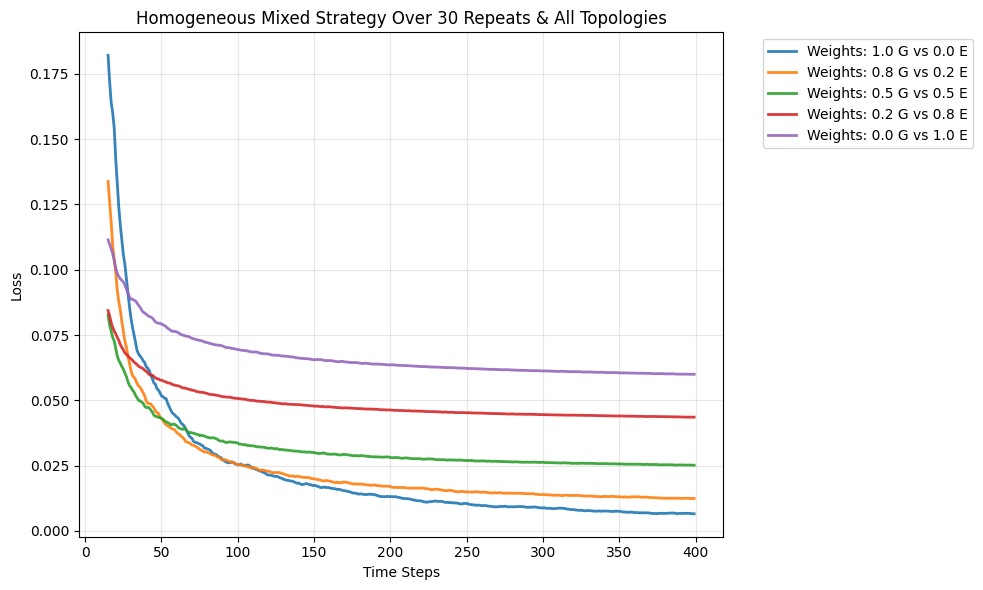

In [5]:
plt.figure(figsize=(10, 6))

for idx, weight_key in enumerate(all_results.keys()):
    all_topologies_average = []
    
    for graph_type in graph_types:
        states_array = np.array(all_results[weight_key][graph_type])
        
        # Calculate the average loss per timestep across the repeats
        avg_state = np.mean(states_array, axis=0)
        all_topologies_average.append(avg_state)

    # Calculate the grand average per timestep over ALL topologies and repeats for THIS pair
    grand_average = np.mean(all_topologies_average, axis=0)
    
    plt.plot(
        time_steps,
        grand_average[training_period:],
        label=f"Weights: {weight_key.replace('_', ' ')}",
        color=colors[idx % len(colors)],
        linewidth=2,
        alpha=0.9
    )

plt.xlabel("Time Steps")
plt.ylabel("Loss")
plt.title(f"Homogeneous Mixed Strategy Over {num_repeats} Repeats & All Topologies")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()